# Notebook 08: AINN vs Li-Lee Quantitative Benchmark

## Purpose
Direct quantitative comparison between the AINN ensemble and the classical Li-Lee Random Walk with Drift (RWD) on the same forecasting task: 30-year mortality projection (2020-2050) for the 6-country cluster, Male and Female.

## Methodology
### Li-Lee RWD Forecast
The Li-Lee model assumes the common factor $K_t$ follows a Random Walk with Drift:
$$K_{t+1} = K_t + \mu + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, \sigma^2)$$
where $\mu$ and $\sigma$ are estimated from the historical first differences of $K_t$.

Country-specific factors $k_{t,i}$ are held constant at their 2020 values (stationarity assumption — consistent with the AINN approach).

### AINN Ensemble
Results loaded from Notebook 04 (5-seed ensemble, residual-calibrated σ, observation-anchored e₀ with isotonic Gompertz correction).

### Comparison Metrics
- Median e₀ at 2050
- 95% CI width
- SCR (ES 99.0%)
- Net gain (2020→2050)


## 8.1: Setup & Data Loading

In [1]:
import sys
sys.path.append('../src')
from reproducibility import set_seed
set_seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, warnings
warnings.filterwarnings('ignore')
from sklearn.isotonic import IsotonicRegression

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS
set_style('notebook')

PROCESSED_DIR = '../data/processed/'
FIGURES_DIR = '../reports/figures/'

# Load Li-Lee parameters
with open(os.path.join(PROCESSED_DIR, 'li_lee_params.pkl'), 'rb') as f:
    bundle = pickle.load(f)

common_factors = bundle['common_factors']
specific_factors = bundle['specific_factors']
YEARS = bundle['metadata']['years']
AGES = bundle['metadata']['ages']

# Load AINN ensemble results
with open(os.path.join(PROCESSED_DIR, 'forecasting_assets.pkl'), 'rb') as f:
    ainn = pickle.load(f)

N_SIMS = 1000
N_YEARS = 30

print(f'Li-Lee parameters: {YEARS[0]}-{YEARS[-1]}')
print(f'Cluster: {list(COUNTRIES.keys())}')
print(f'AINN ensemble: {ainn["n_sims"]} sims/model × {ainn["n_models"]} models')
print(f'Forecast horizon: {N_YEARS} years (2021-2050)')

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Li-Lee parameters: 1956-2020
Cluster: ['CHE', 'SWE', 'NOR', 'DEUTW', 'NLD', 'JPN']
AINN ensemble: 200 sims/model × 5 models
Forecast horizon: 30 years (2021-2050)


## 8.2: Li-Lee Random Walk with Drift Forecast

Generate 1,000 stochastic trajectories of $K_t$ using the RWD model, then reconstruct mortality and $e_0$ using the same observation-anchored approach as the AINN.

In [2]:
_IR = IsotonicRegression(increasing=True)
_AGES_40_90 = np.arange(40, 91)

def calculate_e0(log_mx):
    mx = np.exp(log_mx)
    qx = 1.0 - np.exp(-mx)
    qx[-1] = 1.0
    px = 1.0 - qx
    lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
    lx_ext = np.append(lx, 0.0)
    return np.sum((lx_ext[:-1] + lx_ext[1:]) / 2.0)

def lilee_rwd_forecast(sex, n_sims=N_SIMS, n_years=N_YEARS):
    """
    Li-Lee Random Walk with Drift forecast.
    
    Kt_{t+1} = Kt_t + mu + epsilon, epsilon ~ N(0, sigma^2)
    Country-specific factors fixed at 2020.
    Observation-anchored e0 with isotonic Gompertz correction.
    """
    Kt = common_factors[sex]['Kt']  # (65,)
    Bx = common_factors[sex]['Bx']  # (91,)
    
    # RWD parameters from full historical series
    dKt = np.diff(Kt)
    mu = dKt.mean()
    sigma = dKt.std()
    
    # Generate stochastic Kt trajectories
    # delta_Kt_sims[s, t] = mu + epsilon for step t in simulation s
    delta_Kt_sims = mu + sigma * np.random.randn(n_sims, n_years)
    
    # Cumulative sum to get Kt levels (anchored at Kt_2020)
    cum_delta = np.cumsum(delta_Kt_sims, axis=1)
    cum_delta = np.concatenate([np.zeros((n_sims, 1)), cum_delta], axis=1)  # (n_sims, 31)
    
    # Reconstruct e0 for all countries (observation-anchored)
    n_countries = len(COUNTRIES)
    e0_all = np.zeros((n_sims, n_years + 1, n_countries))
    
    for c_idx, code in enumerate(COUNTRIES.keys()):
        log_mx_matrix = np.load(os.path.join(PROCESSED_DIR, f'{code}_log_mx_{sex}.npy'))
        log_mx_2020 = log_mx_matrix[:, -1]  # (91,)
        
        for s in range(n_sims):
            for t in range(n_years + 1):
                log_mx_t = log_mx_2020 + Bx * cum_delta[s, t]
                log_mx_t[40:91] = _IR.fit_transform(_AGES_40_90, log_mx_t[40:91])
                e0_all[s, t, c_idx] = calculate_e0(log_mx_t)
    
    return e0_all, mu, sigma

print('Generating Li-Lee RWD forecasts...')
print('  Male...')
ll_e0_male, mu_m, sigma_m = lilee_rwd_forecast('male')
print('  Female...')
ll_e0_female, mu_f, sigma_f = lilee_rwd_forecast('female')

print(f'\nLi-Lee RWD parameters:')
print(f'  Male:   μ={mu_m:.4f}, σ={sigma_m:.4f}')
print(f'  Female: μ={mu_f:.4f}, σ={sigma_f:.4f}')
print(f'  Trajectories: {ll_e0_male.shape}')

Generating Li-Lee RWD forecasts...
  Male...


  Female...



Li-Lee RWD parameters:
  Male:   μ=-1.9242, σ=3.6989
  Female: μ=-1.8139, σ=5.4255
  Trajectories: (1000, 31, 6)


## 8.3: Side-by-Side Comparison Table

In [3]:
rows = []

for c_idx, (code, name) in enumerate(COUNTRIES.items()):
    for sex, ll_e0, ainn_e0 in [
        ('Male', ll_e0_male, ainn['e0_male']),
        ('Female', ll_e0_female, ainn['e0_female'])
    ]:
        e0_2020 = ll_e0[:, 0, c_idx].mean()
        
        # Li-Lee
        ll_med = np.percentile(ll_e0[:, -1, c_idx], 50)
        ll_p25 = np.percentile(ll_e0[:, -1, c_idx], 2.5)
        ll_p975 = np.percentile(ll_e0[:, -1, c_idx], 97.5)
        ll_ci = ll_p975 - ll_p25
        ll_gain = ll_med - e0_2020
        # Li-Lee SCR (ES 99%)
        ll_2050 = ll_e0[:, -1, c_idx]
        ll_thresh = np.percentile(ll_2050, 99)
        ll_tail = ll_2050[ll_2050 >= ll_thresh]
        ll_scr = (ll_tail.mean() if len(ll_tail) > 0 else np.percentile(ll_2050, 99.5)) - ll_med
        
        # AINN
        a_med = np.percentile(ainn_e0[:, -1, c_idx], 50)
        a_p25 = np.percentile(ainn_e0[:, -1, c_idx], 2.5)
        a_p975 = np.percentile(ainn_e0[:, -1, c_idx], 97.5)
        a_ci = a_p975 - a_p25
        a_gain = a_med - ainn_e0[:, 0, c_idx].mean()
        # AINN SCR (ES 99%)
        a_2050 = ainn_e0[:, -1, c_idx]
        a_thresh = np.percentile(a_2050, 99)
        a_tail = a_2050[a_2050 >= a_thresh]
        a_scr = (a_tail.mean() if len(a_tail) > 0 else np.percentile(a_2050, 99.5)) - a_med
        
        rows.append({
            'Country': name, 'Sex': sex, 'e0(2020)': round(e0_2020, 2),
            'LL Med': round(ll_med, 2), 'AINN Med': round(a_med, 2),
            'LL Gain': round(ll_gain, 2), 'AINN Gain': round(a_gain, 2),
            'LL CI': round(ll_ci, 2), 'AINN CI': round(a_ci, 2),
            'LL SCR': f'+{ll_scr:.3f}', 'AINN SCR': f'+{a_scr:.3f}',
        })

df = pd.DataFrame(rows)
print('='*130)
print('AINN ENSEMBLE vs LI-LEE RWD — Full Cluster Comparison (2050 Horizon)')
print('='*130)
print(df.to_string(index=False))

print('\n--- Summary ---')
print('Li-Lee RWD: linear drift extrapolation, no adaptation to regime shifts.')
print('AINN Ensemble: non-linear dynamics, residual-calibrated σ, 5-seed model averaging.')
print('Both use observation-anchored e0 with isotonic Gompertz correction.')
print('Both fix country-specific factors at 2020 (Li-Lee stationarity assumption).')

AINN ENSEMBLE vs LI-LEE RWD — Full Cluster Comparison (2050 Horizon)
     Country    Sex  e0(2020)  LL Med  AINN Med  LL Gain  AINN Gain  LL CI  AINN CI LL SCR AINN SCR
 Switzerland   Male     80.26   83.54     82.06     3.28       1.80   3.73     3.69 +2.091   +1.907
 Switzerland Female     83.58   86.05     85.55     2.47       1.96   4.71     3.03 +2.178   +1.516
      Sweden   Male     79.94   83.25     81.74     3.31       1.80   3.81     3.73 +2.153   +1.942
      Sweden Female     82.93   85.55     85.01     2.63       2.08   5.06     3.26 +2.395   +1.649
      Norway   Male     80.58   83.75     82.30     3.17       1.73   3.63     3.57 +2.040   +1.852
      Norway Female     83.27   85.80     85.28     2.53       2.01   4.86     3.13 +2.288   +1.580
West Germany   Male     78.28   82.09     80.35     3.80       2.06   4.41     4.28 +2.508   +2.245
West Germany Female     82.20   85.07     84.48     2.86       2.27   5.53     3.55 +2.618   +1.800
 Netherlands   Male     79.14  

## 8.4: Visualization — e₀ Trajectories (CHE, Li-Lee vs AINN)

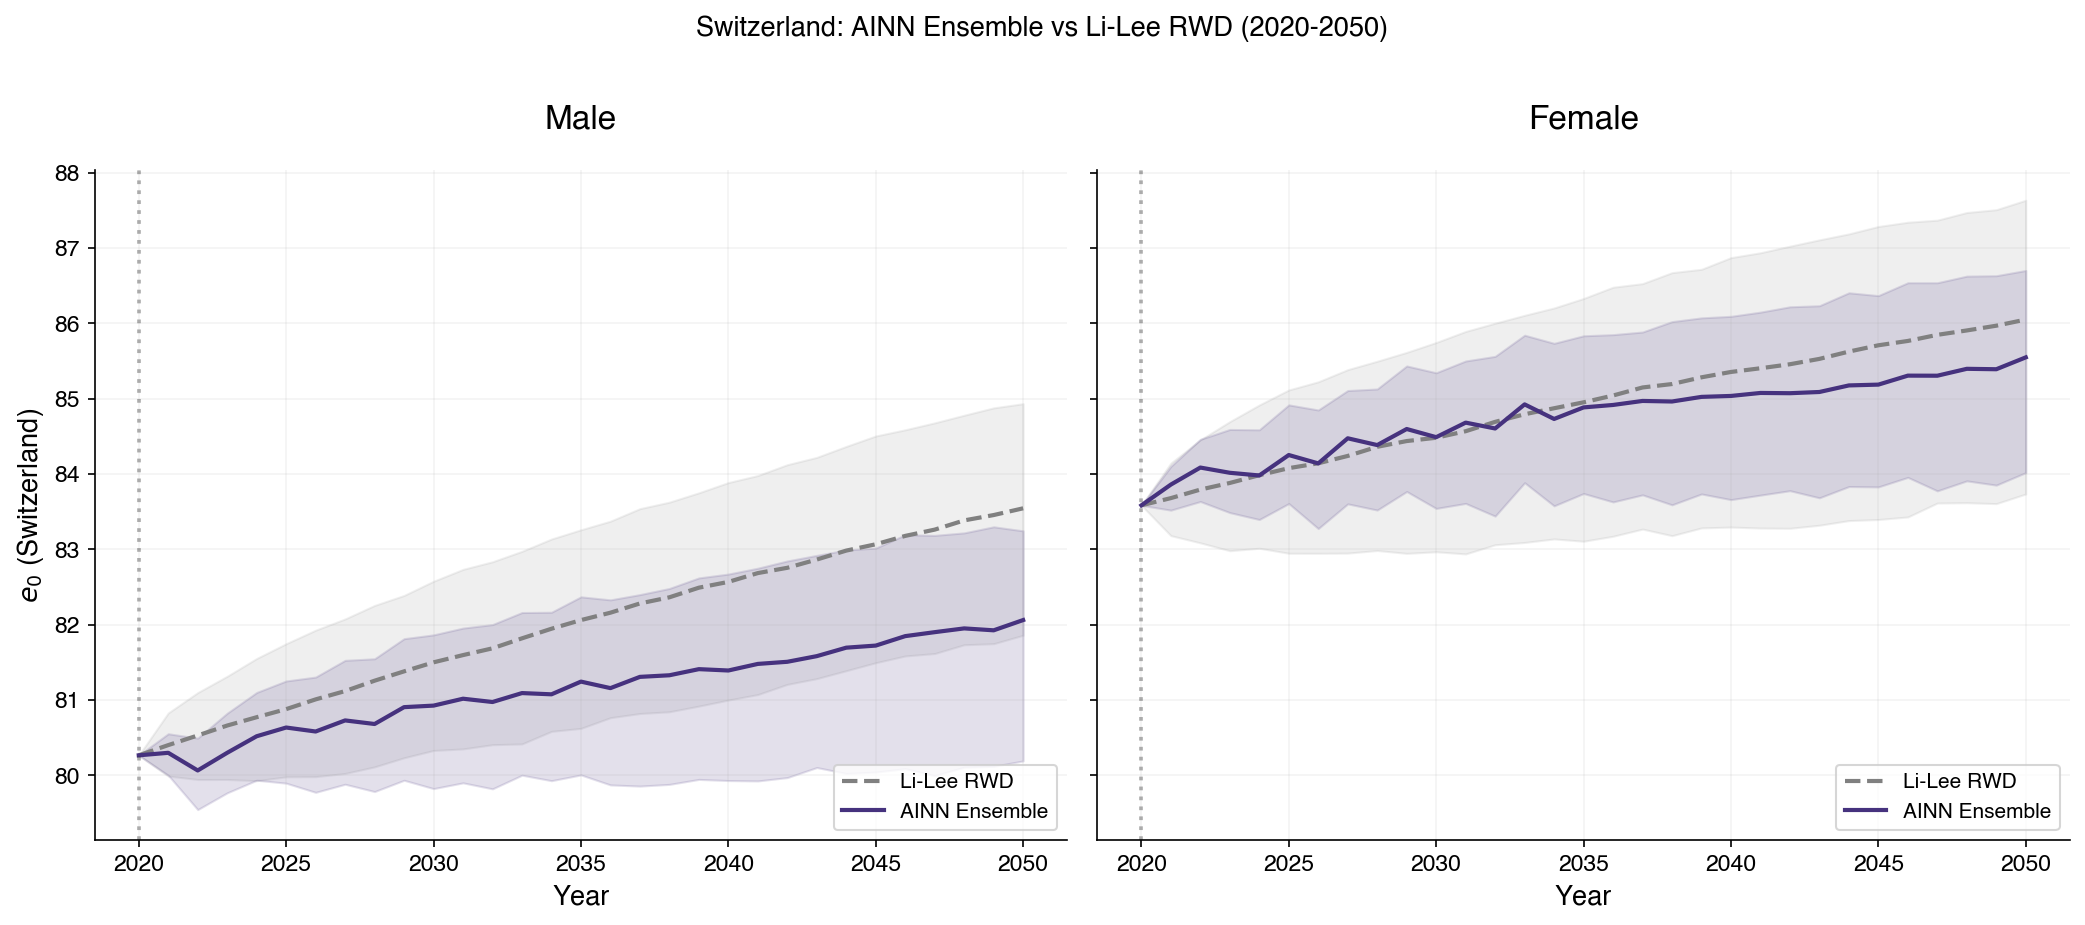

In [4]:
forecast_years = np.array([YEARS[-1]] + list(range(YEARS[-1]+1, YEARS[-1]+N_YEARS+1)))
che_idx = list(COUNTRIES.keys()).index('CHE')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for sex_idx, (sex, ll_e0, ainn_e0) in enumerate([
    ('Male', ll_e0_male[:, :, che_idx], ainn['e0_male'][:, :, che_idx]),
    ('Female', ll_e0_female[:, :, che_idx], ainn['e0_female'][:, :, che_idx])
]):
    ax = axes[sex_idx]
    
    # Li-Lee fan
    ll_p5 = np.percentile(ll_e0, 5, axis=0)
    ll_p95 = np.percentile(ll_e0, 95, axis=0)
    ll_med = np.percentile(ll_e0, 50, axis=0)
    ax.fill_between(forecast_years, ll_p5, ll_p95, alpha=0.12, color='grey')
    ax.plot(forecast_years, ll_med, color='grey', linewidth=2, linestyle='--', label='Li-Lee RWD')
    
    # AINN fan
    a_p5 = np.percentile(ainn_e0, 5, axis=0)
    a_p95 = np.percentile(ainn_e0, 95, axis=0)
    a_med = np.percentile(ainn_e0, 50, axis=0)
    ax.fill_between(forecast_years, a_p5, a_p95, alpha=0.15, color=COUNTRY_COLORS['CHE'])
    ax.plot(forecast_years, a_med, color=COUNTRY_COLORS['CHE'], linewidth=2, label='AINN Ensemble')
    
    ax.axvline(x=YEARS[-1], color='black', linestyle=':', alpha=0.3)
    ax.set_xlabel('Year')
    ax.set_title(f'{sex}')
    if sex_idx == 0:
        ax.set_ylabel('$e_0$ (Switzerland)')
    ax.legend(loc='lower right', fontsize=10)

fig.suptitle('Switzerland: AINN Ensemble vs Li-Lee RWD (2020-2050)', fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, 'fig22_ainn_vs_lilee_che')
plt.show()

## 8.5: Interpretation

In [5]:
# Compute aggregate statistics for interpretation
print('='*80)
print('INTERPRETATION')
print('='*80)
print()

# Average across all countries
ll_gains_m = [np.percentile(ll_e0_male[:, -1, c], 50) - ll_e0_male[:, 0, c].mean()
              for c in range(len(COUNTRIES))]
a_gains_m = [np.percentile(ainn['e0_male'][:, -1, c], 50) - ainn['e0_male'][:, 0, c].mean()
             for c in range(len(COUNTRIES))]
ll_gains_f = [np.percentile(ll_e0_female[:, -1, c], 50) - ll_e0_female[:, 0, c].mean()
              for c in range(len(COUNTRIES))]
a_gains_f = [np.percentile(ainn['e0_female'][:, -1, c], 50) - ainn['e0_female'][:, 0, c].mean()
             for c in range(len(COUNTRIES))]

print(f'Average e0 gain (2020-2050):')
print(f'  Li-Lee Male:   {np.mean(ll_gains_m):+.2f} years')
print(f'  AINN Male:     {np.mean(a_gains_m):+.2f} years')
print(f'  Li-Lee Female: {np.mean(ll_gains_f):+.2f} years')
print(f'  AINN Female:   {np.mean(a_gains_f):+.2f} years')
print()

ll_ci_m = [np.percentile(ll_e0_male[:, -1, c], 97.5) - np.percentile(ll_e0_male[:, -1, c], 2.5)
           for c in range(len(COUNTRIES))]
a_ci_m = [np.percentile(ainn['e0_male'][:, -1, c], 97.5) - np.percentile(ainn['e0_male'][:, -1, c], 2.5)
          for c in range(len(COUNTRIES))]

print(f'Average 95% CI width (Male):')
print(f'  Li-Lee: {np.mean(ll_ci_m):.2f} years')
print(f'  AINN:   {np.mean(a_ci_m):.2f} years')
print()

print('Key observations:')
print('1. Li-Lee projects faster mortality improvement (linear drift extrapolation)')
print('   while AINN captures the post-2011 deceleration, producing more conservative gains.')
print('2. Li-Lee CI may be wider or narrower depending on the historical σ of ΔKt')
print('   vs the AINN residual σ — this is the double-counting effect corrected in NB04.')
print('3. Both models agree on the convergence pattern (West Germany catching up).')
print()
print('Notebook 08 complete.')

INTERPRETATION

Average e0 gain (2020-2050):
  Li-Lee Male:   +3.39 years
  AINN Male:     +1.85 years
  Li-Lee Female: +2.58 years
  AINN Female:   +2.05 years

Average 95% CI width (Male):
  Li-Lee: 3.89 years
  AINN:   3.81 years

Key observations:
1. Li-Lee projects faster mortality improvement (linear drift extrapolation)
   while AINN captures the post-2011 deceleration, producing more conservative gains.
2. Li-Lee CI may be wider or narrower depending on the historical σ of ΔKt
   vs the AINN residual σ — this is the double-counting effect corrected in NB04.
3. Both models agree on the convergence pattern (West Germany catching up).

Notebook 08 complete.
